# Additive Transcription
I'm interested if the combination of experiencing hypoxia and warming together results in additive transcription (the effect of experiencing both is the sum of experiencing the single stressors).

Following a pipeline from [Jordine et al 2026](https://link-springer-com.umasslowell.idm.oclc.org/content/pdf/10.1186/s12870-026-08595-7.pdf) - they looked at hypoxia and salt stress in plants.

## 0. load libraries

In [2]:
library(tidyverse)

## 1. read CSVs
The paper used only pairwise comparisons that used control conditions as the reference - so here, I want to pull out B vs. C, H vs. C, and W vs. C comparisons

In [4]:
bc <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/new_refGenome/deseq_res/p1.both_v_cont.csv')
hc <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/new_refGenome/deseq_res/p1.hyp_v_cont.csv')
wc <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/new_refGenome/deseq_res/p1.warm_v_cont.csv')
head(bc)

,X,Gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,svalue,B1_Nu_O03,⋯,H3_Nu_B18,H4_Nu_B28,H5_Nu_B35,H6_Nu_B45,W1_Nu_G02,W2_Nu_G15,W3_Nu_G21,W4_Nu_G27,W6_Nu_G41,W6_Nu_G45
,<int>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1,LOC144621260,2772.7661933,0.001099644,0.02833019,0.2814888,7.783355e-01,0.995808237,0.983397704,2271.416959,⋯,3206.1520,2174.44210,3121.1982,3981.9695,2535.180572,2754.7438,2174.758630,3212.902997,2713.438543,2987.74998
2,2,LOC144621269,6797.3813723,0.004800664,0.11126853,0.5786176,5.628473e-01,0.986620041,0.966164978,497.327987,⋯,9120.5983,2304.77446,224.9419,47354.7857,8749.519474,2960.5170,3645.645765,11016.987102,1.984959,5076.90961
3,3,LOC111120925,191.4430470,-4.816060784,1.43459226,-4.4327870,9.302274e-06,0.003032661,0.003332593,3.429848,⋯,383.2612,14.37489,246.7104,219.6858,6.742502,337.8011,5.571542,6.466452,0.000000,13.84383
4,4,Trnae-cuc,0.0000000,0.000000000,1.38548257,NA,NA,NA,0.882845125,0.000000,⋯,0.0000,0.00000,0.0000,0.0000,0.000000,0.0000,0.000000,0.000000,0.000000,0.00000
5,5,Trnae-cuc-2,0.0000000,0.000000000,1.38548257,NA,NA,NA,0.882873339,0.000000,⋯,0.0000,0.00000,0.0000,0.0000,0.000000,0.0000,0.000000,0.000000,0.000000,0.00000
6,6,Trnae-cuc-3,0.3001343,0.003698284,0.33904697,0.1418243,8.872188e-01,NA,0.954833396,0.000000,⋯,0.0000,0.00000,0.0000,0.0000,0.000000,0.0000,0.000000,0.000000,0.000000,0.00000


## 2. identify B vs. C DEGs
get list of significantly differentially expressed genes from the both vs. control comparison

In [25]:
bc.deg <- bc %>%
filter(padj < 0.05 & abs(log2FoldChange) > 1) %>%
select(Gene, lfc_both = log2FoldChange)


dim(bc.deg) # 255 DEGs
head(bc.deg)

[1] 255   2

,Gene,lfc_both
,<chr>,<dbl>
1,LOC111120925,-4.816061
2,LOC111103173,4.365504
3,LOC144622019,-21.685053
4,LOC111105159,-5.199942
5,LOC111132252,-2.635506
6,LOC111137262,3.622591


### pull B vs. C DEGs from other comparisons

In [21]:
# WARM vs. CONTROL
wc.genes <- wc %>%
filter(Gene %in% bc.deg$Gene) %>%
select(Gene, log2FoldChange, padj) 

dim(wc.genes)

# HYPOXIC vs. CONTROL
hc.genes <- hc %>%
filter(Gene %in% bc.deg$Gene) %>%
select(Gene, log2FoldChange, padj)

dim(hc.genes)
head(hc.genes)

[1] 255   3

[1] 255   3

,Gene,log2FoldChange,padj
,<chr>,<dbl>,<dbl>
1,LOC111120925,-0.006471049,9.302162e-01
2,LOC111103173,0.004725946,9.650183e-01
3,LOC144622019,-22.148832890,1.134672e-05
4,LOC111105159,-0.131328797,4.786011e-01
5,LOC111132252,0.002642125,9.844600e-01
6,LOC111137262,1.622017472,9.637933e-02


In [20]:
merged <- wc.genes %>%
  select(Gene, lfc_warm = log2FoldChange) %>%
  inner_join(
    hc.genes %>%
      select(Gene, lfc_hypoxia = log2FoldChange),
    by = "Gene"
  ) %>%
  mutate(expected_lfc = lfc_warm + lfc_hypoxia)

head(merged)

,Gene,lfc_warm,lfc_hypoxia,expected_lfc
,<chr>,<dbl>,<dbl>,<dbl>
1,LOC111120925,-0.161728411,-0.006471049,-0.168199460
2,LOC111103173,0.024309240,0.004725946,0.029035187
3,LOC144622019,-21.956159932,-22.148832890,-44.104992822
4,LOC111105159,-4.158366433,-0.131328797,-4.289695230
5,LOC111132252,-0.005228605,0.002642125,-0.002586481
6,LOC111137262,2.708825236,1.622017472,4.330842708


In [26]:
merged.df <- merge(bc.deg, merged, by = 'Gene')

dim(merged.df)
head(merged.df)

[1] 255   5

,Gene,lfc_both,lfc_warm,lfc_hypoxia,expected_lfc
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC111099801,-7.692004,0.003592758,-1.558676e-06,0.003591200
2,LOC111099828,-6.387132,-0.011298177,-2.345331e-03,-0.013643508
3,LOC111099841,-6.840928,-0.029329211,2.579381e-04,-0.029071273
4,LOC111099910,-4.620075,-0.109431746,-1.936194e-03,-0.111367940
5,LOC111099974,-8.402842,-0.107588565,-5.327649e-03,-0.112916214
6,LOC111100030,-22.359733,-0.006373850,1.002508e-03,-0.005371342


## 3. plot both vs. sum(single)

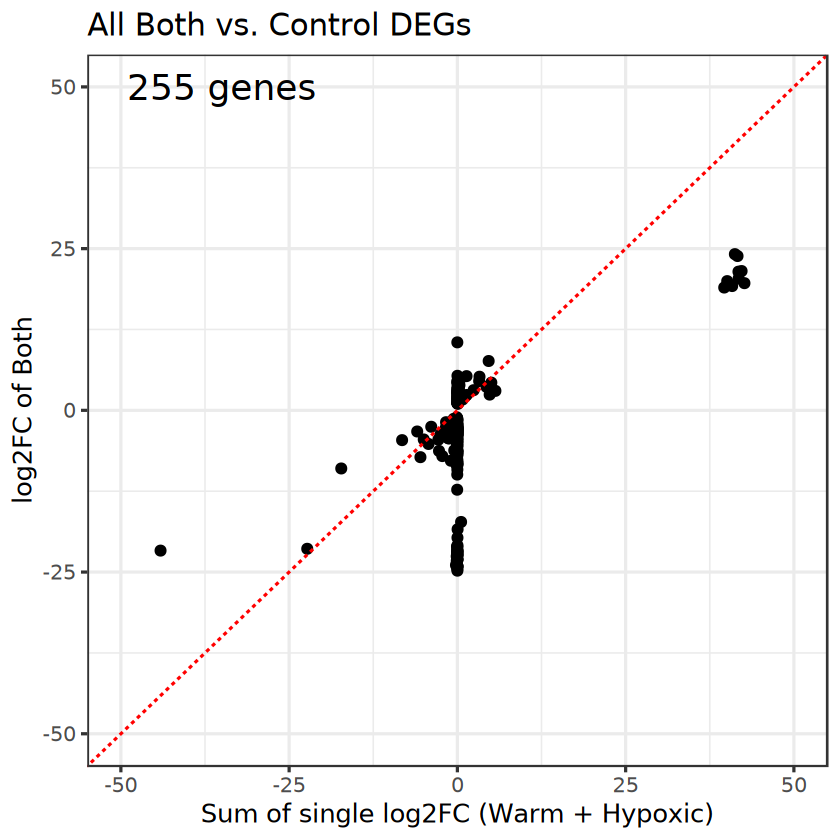

In [42]:
ggplot(merged.df, aes(x = expected_lfc, y = lfc_both)) +
geom_point() +

# add 1:1 line
geom_abline(slope = 1, intercept = 0, color = "red", linetype = "dashed") +

# keep axes the same
ylim(-50,50) +
xlim(-50,50) +

# add text to plot
annotate("text", x = -35, y = 50, label = "255 genes", color = "black", size = 7.5) +

# theme and labels
labs(x = 'Sum of single log2FC (Warm + Hypoxic)',
    y = 'log2FC of Both',
    title = 'All Both vs. Control DEGs') +
theme_bw(base_size = 15)

**observations**:
- some of the genes that had no expression changes for single stressor vs. control had very large changes when both stressors are experienced simultaneously (all the points on the 0 x-axis line)
- points below the 1:1 line - the sum of the single stressors was larger than the expression change of both stressors - **divergent or antagonistic expression**
- points above the 1:1 line - the sum of the single stressors was less than the expression change of both stressors - **enhanced or synergistic expression**
- points on the 1:1 line - the sum is the same as the combined effect - **additive expression**

would have to go back and statistically assign additive/divergent/enhanced 